# Partie 2 : Implémentation "From Scratch" (Numpy) - SOLUTIONS

**Objectif :** Comprendre la mécanique interne et la règle de mise à jour des poids.

**Outils :** Python, NumPy, Matplotlib.

---

## Contexte Mathématique

On rappelle la règle de mise à jour des poids pour un Perceptron simple (Rosenblatt) :

$$\Delta w = \eta \cdot (y - \hat{y}) \cdot x$$

Où $\eta$ est le taux d'apprentissage (learning rate).

---

## Exercice 2.1 : La Classe Perceptron (Solution complète)


In [19]:
import numpy as np
import matplotlib.pyplot as plt

class Perceptron:
    def __init__(self, learning_rate=0.01, n_iters=1000):
        self.lr = learning_rate
        self.n_iters = n_iters
        self.weights = None
        self.bias = None
        self.accuracy_history = []

    def activation(self, x):
        """Fonction Heaviside : retourne 1 si x >= 0, sinon 0"""
        return np.where(x >= 0, 1, 0)

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        self.accuracy_history = []

        for _ in range(self.n_iters):
            for idx, x_i in enumerate(X):
                # 1. Calculer la sortie linéaire (z = w.x + b)
                linear_output = np.dot(x_i, self.weights) + self.bias
                
                # 2. Appliquer l'activation pour avoir y_predicted
                y_predicted = self.activation(linear_output)
                
                # 3. SOLUTION: Appliquer la règle de mise à jour
                # Règle de Rosenblatt: Δw = η * (y - ŷ) * x
                update = self.lr * (y[idx] - y_predicted)
                self.weights += update * x_i
                self.bias += update
            
            # Calculer et stocker l'accuracy à chaque époque
            predictions = self.predict(X)
            accuracy = np.mean(predictions == y)
            self.accuracy_history.append(accuracy)

    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        return self.activation(linear_output)


---

## Exercice 2.2 : Porte ET (AND)


In [20]:
# Dataset AND
X_and = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])
y_and = np.array([0, 0, 0, 1])  # Sortie: 1 seulement si les deux entrées sont 1

# Entraînement
perceptron_and = Perceptron(learning_rate=0.1, n_iters=100)
perceptron_and.fit(X_and, y_and)

# Affichage des poids finaux et du bias
print("=" * 50)
print("PORTE AND")
print("=" * 50)
print(f"Poids: {perceptron_and.weights}")
print(f"Bias: {perceptron_and.bias}")

# Test des prédictions
predictions_and = perceptron_and.predict(X_and)
print(f"\nPrédictions: {predictions_and}")
print(f"Attendu:     {y_and}")

# Vérification
accuracy_and = np.mean(predictions_and == y_and)
print(f"\nAccuracy: {accuracy_and * 100:.0f}%")
print("Le perceptron résout correctement la porte AND!" if accuracy_and == 1.0 else "Erreur")


PORTE AND
Poids: [0.2 0.1]
Bias: -0.20000000000000004

Prédictions: [0 0 0 1]
Attendu:     [0 0 0 1]

Accuracy: 100%
Le perceptron résout correctement la porte AND!


---

## Exercice 2.3 : Porte OU Exclusif (XOR)


In [21]:
# Dataset XOR
X_xor = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])
y_xor = np.array([0, 1, 1, 0])  # Sortie: 1 si exactement une entrée est 1

perceptron_xor = Perceptron(learning_rate=0.1, n_iters=100)
perceptron_xor.fit(X_xor, y_xor)

print("=" * 50)
print("PORTE XOR")
print("=" * 50)
predictions_xor = perceptron_xor.predict(X_xor)
print(f"Prédictions: {predictions_xor}")
print(f"Attendu:     {y_xor}")

accuracy_xor = np.mean(predictions_xor == y_xor)
print(f"\nAccuracy: {accuracy_xor * 100:.0f}%")


PORTE XOR
Prédictions: [1 1 0 0]
Attendu:     [0 1 1 0]

Accuracy: 50%


### Observation

Le modèle **N'ARRIVE PAS** à converger sur le XOR !

- L'accuracy reste à **50%** (équivalent au hasard pour 2 classes)
- Les poids oscillent sans jamais trouver une solution

**Pourquoi ?**

Le problème XOR n'est **PAS linéairement séparable**. Il est impossible de tracer une seule ligne droite qui sépare les points (0,0) et (1,1) des points (0,1) et (1,0).

> C'est cette limitation fondamentale qui a mené à "l'hiver de l'IA" dans les années 1970, jusqu'à la découverte de la rétropropagation et des réseaux multicouches (MLP).

---

## Exercice 2.4 (Bonus) : Courbes d'apprentissage


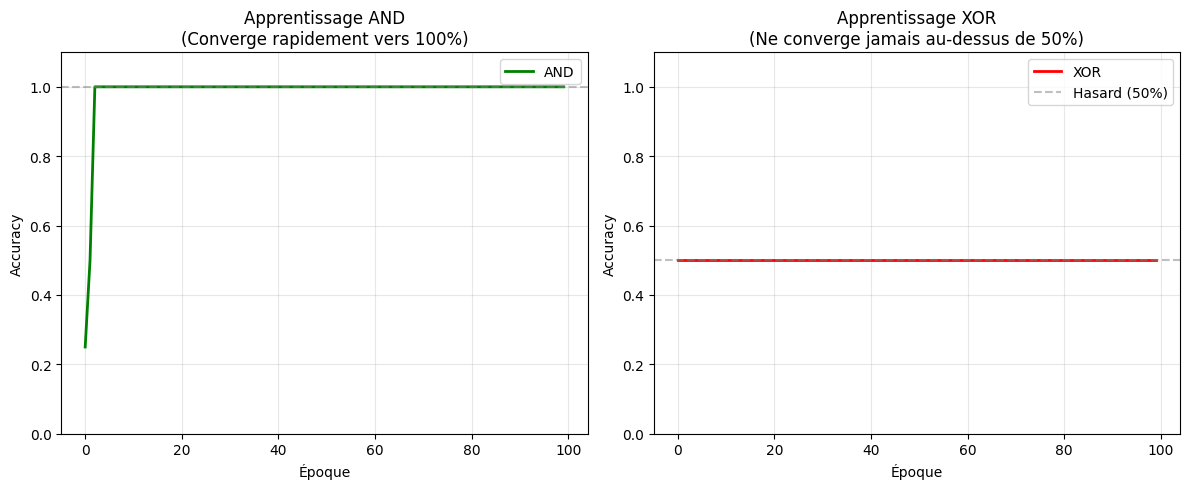

In [22]:
# Tracé des courbes d'apprentissage
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(perceptron_and.accuracy_history, 'g-', linewidth=2, label='AND')
plt.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('Époque')
plt.ylabel('Accuracy')
plt.title('Apprentissage AND\n(Converge rapidement vers 100%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim([0, 1.1])

plt.subplot(1, 2, 2)
plt.plot(perceptron_xor.accuracy_history, 'r-', linewidth=2, label='XOR')
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Hasard (50%)')
plt.xlabel('Époque')
plt.ylabel('Accuracy')
plt.title('Apprentissage XOR\n(Ne converge jamais au-dessus de 50%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim([0, 1.1])

plt.tight_layout()
plt.show()


# Partie 2 : Implémentation "From Scratch" (Numpy)

**Objectif :** Comprendre la mécanique interne et la règle de mise à jour des poids.

**Outils :** Python, NumPy, Matplotlib.

---

## Contexte Mathématique

On rappelle la règle de mise à jour des poids pour un Perceptron simple (Rosenblatt) :

$$\Delta w = \eta \cdot (y - \hat{y}) \cdot x$$

Où $\eta$ est le taux d'apprentissage (learning rate).


## Exercice 2.1 : La Classe Perceptron (Solution complète)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

class Perceptron:
    def __init__(self, learning_rate=0.01, n_iters=1000):
        self.lr = learning_rate
        self.n_iters = n_iters
        self.weights = None
        self.bias = None
        self.accuracy_history = []  # Pour le bonus (Exercice 2.4)

    def activation(self, x):
        """Fonction Heaviside : retourne 1 si x >= 0, sinon 0"""
        return np.where(x >= 0, 1, 0)

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        self.accuracy_history = []

        for _ in range(self.n_iters):
            for idx, x_i in enumerate(X):
                # 1. Calculer la sortie linéaire (z = w.x + b)
                linear_output = np.dot(x_i, self.weights) + self.bias
                
                # 2. Appliquer l'activation pour avoir y_predicted
                y_predicted = self.activation(linear_output)
                
                # 3. Appliquer la règle de mise à jour
                # Règle de Rosenblatt: Δw = η * (y - ŷ) * x
                update = self.lr * (y[idx] - y_predicted)
                self.weights += update * x_i
                self.bias += update
            
            # Bonus: Calculer et stocker l'accuracy à chaque époque
            predictions = self.predict(X)
            accuracy = np.mean(predictions == y)
            self.accuracy_history.append(accuracy)

    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        return self.activation(linear_output)


---

## Exercice 2.2 : Porte ET (AND)


In [ ]:
# Dataset AND
X_and = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])
y_and = np.array([0, 0, 0, 1])  # Sortie: 1 seulement si les deux entrées sont 1

# Entraînement
perceptron_and = Perceptron(learning_rate=0.1, n_iters=100)
perceptron_and.fit(X_and, y_and)

# Affichage des poids finaux et du bias
print("=" * 50)
print("PORTE AND")
print("=" * 50)
print(f"Poids: {perceptron_and.weights}")
print(f"Bias: {perceptron_and.bias}")

# Test des prédictions
predictions_and = perceptron_and.predict(X_and)
print(f"\nPrédictions: {predictions_and}")
print(f"Attendu:     {y_and}")

# Vérification
accuracy_and = np.mean(predictions_and == y_and)
print(f"\nAccuracy: {accuracy_and * 100:.0f}%")
print("Le perceptron résout correctement la porte AND!" if accuracy_and == 1.0 else "Erreur!")


PORTE AND
Poids: [0.2 0.1]
Bias: -0.20000000000000004

Prédictions: [0 0 0 1]
Attendu:     [0 0 0 1]

Accuracy: 100%
Le perceptron résout correctement la porte AND!


---

## Exercice 2.3 : Porte OU Exclusif (XOR)


In [25]:
# Dataset XOR
X_xor = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])
y_xor = np.array([0, 1, 1, 0])  # Sortie: 1 si exactement une entrée est 1

# Entraînement
perceptron_xor = Perceptron(learning_rate=0.1, n_iters=100)
perceptron_xor.fit(X_xor, y_xor)

# Test des prédictions
print("=" * 50)
print("PORTE XOR")
print("=" * 50)
predictions_xor = perceptron_xor.predict(X_xor)
print(f"Prédictions: {predictions_xor}")
print(f"Attendu:     {y_xor}")

# Calcul de l'accuracy
accuracy_xor = np.mean(predictions_xor == y_xor)
print(f"\nAccuracy: {accuracy_xor * 100:.0f}%")


PORTE XOR
Prédictions: [1 1 0 0]
Attendu:     [0 1 1 0]

Accuracy: 50%


### Observation

Le modèle **N'ARRIVE PAS** à converger sur le XOR !

- L'accuracy reste à **50%** (équivalent au hasard pour 2 classes)
- Les poids oscillent sans jamais trouver une solution

**Pourquoi ?**

Le problème XOR n'est **PAS linéairement séparable**. Il est impossible de tracer une seule ligne droite qui sépare les points (0,0) et (1,1) des points (0,1) et (1,0).

> C'est cette limitation fondamentale qui a mené à "l'hiver de l'IA" dans les années 1970, jusqu'à la découverte de la rétropropagation et des réseaux multicouches (MLP).

---

## Exercice 2.4 : Courbes d'apprentissage


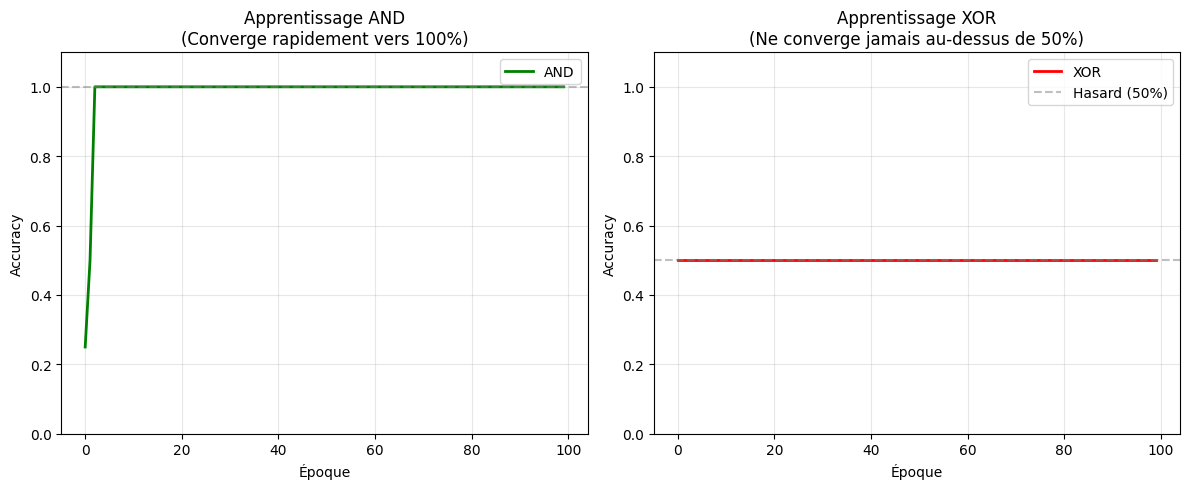

In [26]:
# Tracé des courbes d'apprentissage
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(perceptron_and.accuracy_history, 'g-', linewidth=2, label='AND')
plt.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('Époque')
plt.ylabel('Accuracy')
plt.title('Apprentissage AND\n(Converge rapidement vers 100%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim([0, 1.1])

plt.subplot(1, 2, 2)
plt.plot(perceptron_xor.accuracy_history, 'r-', linewidth=2, label='XOR')
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Hasard (50%)')
plt.xlabel('Époque')
plt.ylabel('Accuracy')
plt.title('Apprentissage XOR\n(Ne converge jamais au-dessus de 50%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim([0, 1.1])

plt.tight_layout()
plt.show()


---

## Bonus : Visualisation des Frontières de Décision


/var/folders/2v/ggjkn6j50d9dkjr4xr25vwcc0000gn/T/ipykernel_69392/3888262703.py:34: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  plt.tight_layout()
/var/folders/2v/ggjkn6j50d9dkjr4xr25vwcc0000gn/T/ipykernel_69392/3888262703.py:34: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from current font.
  plt.tight_layout()


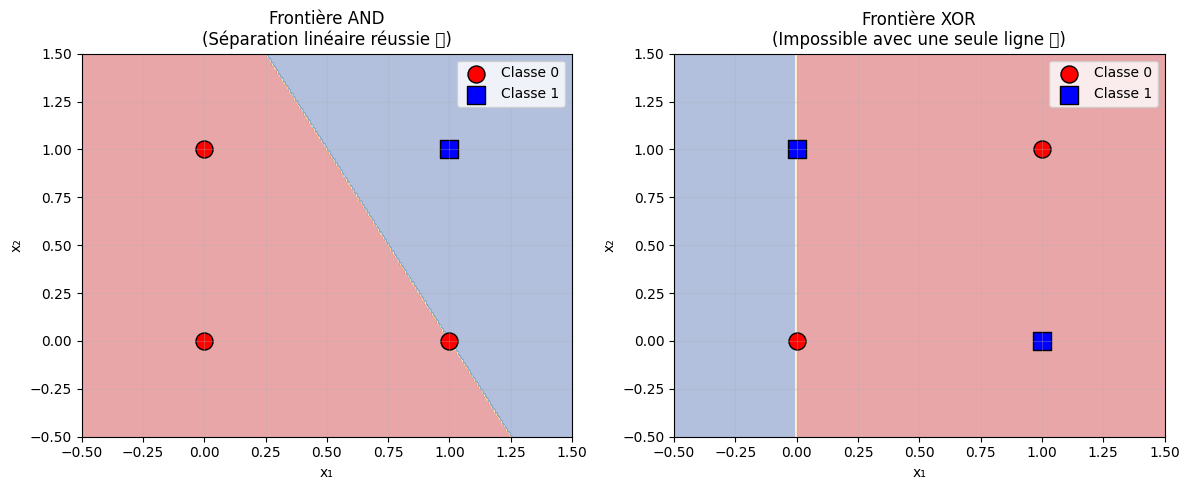

In [ ]:
def plot_decision_boundary(perceptron, X, y, title):
    """Visualise la frontière de décision d'un perceptron"""
    # Créer une grille
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    
    # Prédictions sur la grille
    Z = perceptron.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Tracé
    plt.contourf(xx, yy, Z, alpha=0.4, cmap='RdYlBu')
    plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], c='red', marker='o', s=150, edgecolors='black', label='Classe 0')
    plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], c='blue', marker='s', s=150, edgecolors='black', label='Classe 1')
    plt.xlabel('x₁')
    plt.ylabel('x₂')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)


plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plot_decision_boundary(perceptron_and, X_and, y_and, 
                       'Frontière AND\n(Séparation linéaire réussie)')

plt.subplot(1, 2, 2)
plot_decision_boundary(perceptron_xor, X_xor, y_xor, 
                       'Frontière XOR\n(Impossible avec une seule ligne)')

plt.tight_layout()
plt.show()
